In [1]:
from functions import *
from UQpy.distributions import Normal, JointIndependent
# Do you want plot with latex font format? Use the cell bellow:
import matplotlib as mpl
mpl.rcParams.update({
                        'font.family': 'serif',
                        'mathtext.fontset': 'cm',
                        'axes.unicode_minus': False
                    })
import seaborn as sns
import numpy as np
import joblib
import pandas as pd

d:\Documentos\ic_victor\myenv\Lib\site-packages\UQpy\__init__.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


#### Dados reais

In [2]:
n_samples = 1
n_latent_samples = 5000

time = np.array([0., 10., 20., 30., 40., 50., 60., 70., 80., 90., 100.])

r = Normal(loc=5., scale=0.8)
s = Normal(loc=2., scale=0.6)
joint = JointIndependent(marginals=[r, s])

x = joint.rvs(n_samples)

R_ref = float(x[0, 0])
S_ref = float(x[0, 1])

print(f'R_ref = {R_ref:.4f}, S_ref = {S_ref:.4f}')

lambdas_real = []
gs = []

for t in time:
    y, df = state_limit_function_time(x, n_latent_samples, t=t)
    lambdas_real.append(y)   # y = [λ1, λ2, λ3, λ4]
    gs.append(df[0])

lambdas_real = np.vstack(lambdas_real)

lambda1_real = lambdas_real[:, 0]
lambda2_real = lambdas_real[:, 1]


R_ref = 4.5458, S_ref = 1.7734


#### Previsão ANN para os mesmos R, S e tempos

In [3]:
model = joblib.load(r'model\ann_model_lambda.joblib')
scaler = joblib.load(r'model\scaler_ann.joblib')

X_ann = pd.DataFrame({
    'R': np.full(len(time), R_ref),
    'S': np.full(len(time), S_ref),
    'Time': time
})

X_ann_scaled = scaler.transform(X_ann)
y_ann = model.predict(X_ann_scaled)

lambda1_ann = y_ann[:, 0]
lambda2_ann = y_ann[:, 1]


#### Gráficos comparativos

##### Lambda 1

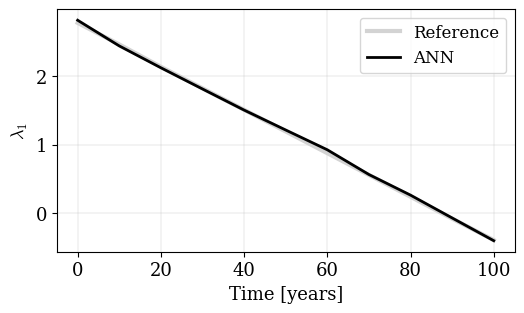

In [ ]:
# =========================
# Figure name and DPI
# =========================
dpi = 600
name = 'lambda1_ann_vs_reference'

# =========================
# Chart dimensions (cm → inches)
# =========================
b_cm = 15
h_cm = 8
inches_to_cm = 1 / 2.54
b_input = b_cm * inches_to_cm
h_input = h_cm * inches_to_cm

# =========================
# Axis and labels
# =========================
label_x = 'Time [years]'
label_y = r'$\lambda_1$'
size_label = 13
color_label = 'black'
size_axis = 13
color_axis = 'black'

# =========================
# Legend
# =========================
legend_label = ['Reference', 'ANN']
size_legend = 12
location_legend = 'best'

# =========================
# Figure
# =========================
fig, ax = plt.subplots(figsize=(b_input, h_input))

# =========================
# Axis config
# =========================
ax.tick_params(axis='both', which='major',
               labelsize=size_axis, colors=color_axis)

ax.set_xlabel(label_x, fontsize=size_label, color=color_label)
ax.set_ylabel(label_y, fontsize=size_label, color=color_label)

# =========================
# Grid
# =========================
plt.grid(True, which='both', linestyle='-', linewidth=0.2)

# =========================
# Plot (cores preservadas)
# =========================
ax.plot(time, lambda1_real,
        color='lightgray', linewidth=3, label=legend_label[0])

ax.plot(time, lambda1_ann,
        color='black', linewidth=2, label=legend_label[1])

# =========================
# Legend
# =========================
ax.legend(fontsize=size_legend, loc=location_legend)

# =========================
# Save
# =========================
#fig.savefig(f'z_{name}.png', dpi=dpi, bbox_inches='tight')

plt.show()



##### Lambda 2

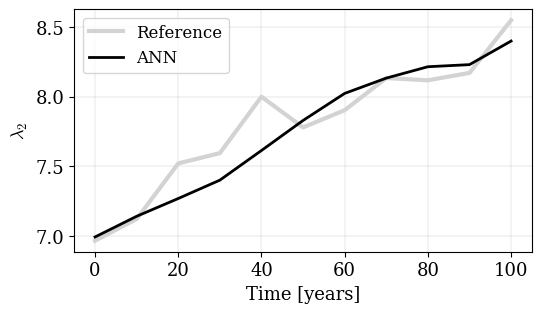

In [ ]:
# =========================
# Figure name and DPI
# =========================
dpi = 600
name = 'lambda2_ann_vs_reference'

# =========================
# Chart dimensions (cm → inches)
# =========================
b_cm = 15
h_cm = 8
inches_to_cm = 1 / 2.54
b_input = b_cm * inches_to_cm
h_input = h_cm * inches_to_cm

# =========================
# Axis and labels
# =========================
label_x = 'Time [years]'
label_y = r'$\lambda_2$'
size_label = 13
color_label = 'black'
size_axis = 13
color_axis = 'black'

# =========================
# Legend
# =========================
legend_label = ['Reference', 'ANN']
size_legend = 12
location_legend = 'best'

# =========================
# Figure
# =========================
fig, ax = plt.subplots(figsize=(b_input, h_input))

# =========================
# Axis config
# =========================
ax.tick_params(axis='both', which='major',
               labelsize=size_axis, colors=color_axis)

ax.set_xlabel(label_x, fontsize=size_label, color=color_label)
ax.set_ylabel(label_y, fontsize=size_label, color=color_label)

# =========================
# Grid
# =========================
plt.grid(True, which='both', linestyle='-', linewidth=0.2)

# =========================
# Plot (cores preservadas)
# =========================
ax.plot(time, lambda2_real,
        color='lightgray', linewidth=3, label=legend_label[0])

ax.plot(time, lambda2_ann,
        color='black', linewidth=2, label=legend_label[1])

# =========================
# Legend
# =========================
ax.legend(fontsize=size_legend, loc=location_legend)

# =========================
# Save
# =========================
#fig.savefig(f'z_{name}.png', dpi=dpi, bbox_inches='tight')

plt.show()


#### Função verdadeira (ground truth)

In [26]:
import numpy as np
import time
import matplotlib.pyplot as plt

# =========================
# Parâmetros
# =========================
n_samples = 1
n_latent_samples = 5000

time_vec = np.arange(0, 100.5, 0.5)

r = Normal(loc=5., scale=0.8)
s = Normal(loc=2., scale=0.6)
joint = JointIndependent(marginals=[r, s])

x = joint.rvs(n_samples)

R_ref = float(x[0, 0])
S_ref = float(x[0, 1])

print(f'R_ref = {R_ref:.4f}, S_ref = {S_ref:.4f}')

# =========================
# Medição de tempo (Ground Truth)
# =========================
start_time = time.time()

lambdas_real = []

for t in time_vec:
    y, df = state_limit_function_time(
        x,
        n_latent_samples,
        t=t
    )
    lambdas_real.append(y)

elapsed_real = time.time() - start_time

lambdas_real = np.vstack(lambdas_real)

# =========================
# Extração
# =========================
lambda1_real = lambdas_real[:, 0]
lambda2_real = lambdas_real[:, 1]
lambda3_real = lambdas_real[:, 2]
lambda4_real = lambdas_real[:, 3]

print(f"Tempo total Ground Truth: {elapsed_real:.4f} s")

R_ref = 5.6316, S_ref = 1.5986
Tempo total Ground Truth: 352.2085 s


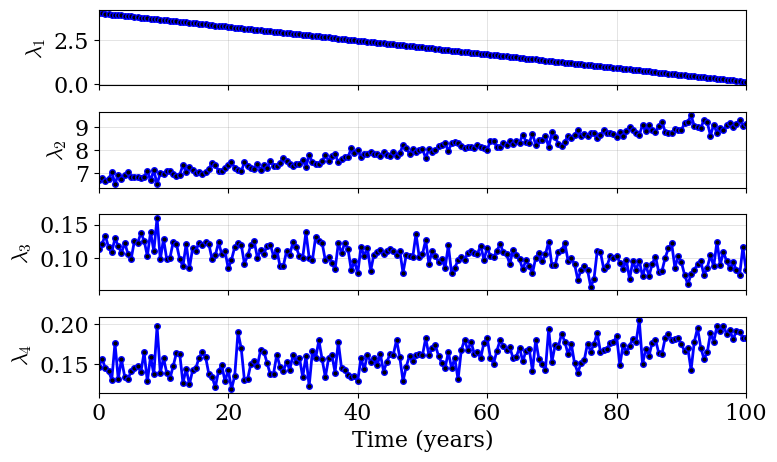

In [ ]:
# =========================
# PLOTAGEM DAS LAMBDAS – GROUND TRUTH
# =========================
import matplotlib.pyplot as plt

### Figure name and DPI
dpi = 600
name = 'lambdas_ground_truth'

### Chart dimensions                                              
b_cm_individual = 5
h_cm = 12
inches_to_cm = 1 / 2.54

n_plots = 4
b_input_total = (b_cm_individual * n_plots) * inches_to_cm
h_input = h_cm * inches_to_cm

### Axis and labels
label_x = 'Time (years)'
size_label = 16
color_label = 'black'
size_axis = 16
color_axis = 'black'

### Line
size_line = 2
style_line = '-'
color_line = 'blue'

### Marker
marker = 'o'
size_marker = 4
color_marker = 'black'
color_marker_edge = color_line

### Grid
on_or_off = False
line_width_grid = 0.5
alpha_grid = 0.3
style_grid = '-'
color_grid = 'gray'

### Labels
labels_legend = [r'$\lambda_1$', r'$\lambda_2$', r'$\lambda_3$', r'$\lambda_4$']

# =========================
# Dados
# =========================
data_gt = [
    {'x': time_vec, 'y': lambda1_real},
    {'x': time_vec, 'y': lambda2_real},
    {'x': time_vec, 'y': lambda3_real},
    {'x': time_vec, 'y': lambda4_real},
]

# =========================
# Figure
# =========================
fig, axes = plt.subplots(nrows=4, ncols=1, sharex=True, figsize=(b_input_total, h_input))

for i, (ax, dataset) in enumerate(zip(axes, data_gt)):
    ax.plot(dataset['x'], dataset['y'],
            marker=marker,
            markersize=size_marker,
            markerfacecolor=color_marker,
            linewidth=size_line,
            linestyle=style_line,
            color=color_line)

    ax.tick_params(axis='both', which='major', labelsize=size_axis, colors=color_axis)
    ax.set_ylabel(labels_legend[i], fontsize=size_label, color=color_label)
    ax.grid(on_or_off, which='both', linestyle=style_grid,
            linewidth=line_width_grid, color=color_grid, alpha=alpha_grid)
    ax.set_xlim(0, 100)

axes[-1].set_xlabel(label_x, fontsize=size_label, color=color_label)

plt.tight_layout()
#fig.savefig(f'z_{name}_en.png', dpi=dpi, bbox_inches='tight')
plt.show()


#### GLAM / surrogate

In [28]:
import numpy as np
import pandas as pd
import joblib
import time
import matplotlib.pyplot as plt

# =========================
# Parâmetros fixos
# =========================
R_ref = 5.0768
S_ref = 1.7969

time_vec = np.arange(0, 100.5, 0.5)

# =========================
# λ3 e λ4 (valores médios da referência)
# =========================
lambda3_mean = np.mean(lambdas_real[:, 2])
lambda4_mean = np.mean(lambdas_real[:, 3])

# =========================
# Carregar modelo GLAM / ANN
# =========================
model = joblib.load(r'model\ann_model_lambda.joblib')
scaler = joblib.load(r'model\scaler_ann.joblib')

# =========================
# Medição de tempo (GLAM)
# =========================
start_time = time.time()

X = pd.DataFrame({
    'R': np.full(len(time_vec), R_ref),
    'S': np.full(len(time_vec), S_ref),
    'Time': time_vec
})

X_scaled = scaler.transform(X)
y_pred = model.predict(X_scaled)

elapsed_glam = time.time() - start_time

lambda1_glam = y_pred[:, 0]
lambda2_glam = y_pred[:, 1]

# =========================
# λ3 e λ4 constantes
# =========================
lambda3_glam = np.full(len(time_vec), lambda3_mean)
lambda4_glam = np.full(len(time_vec), lambda4_mean)

print(f"Tempo total GLAM / ANN: {elapsed_glam:.4f} s")


Tempo total GLAM / ANN: 0.0063 s


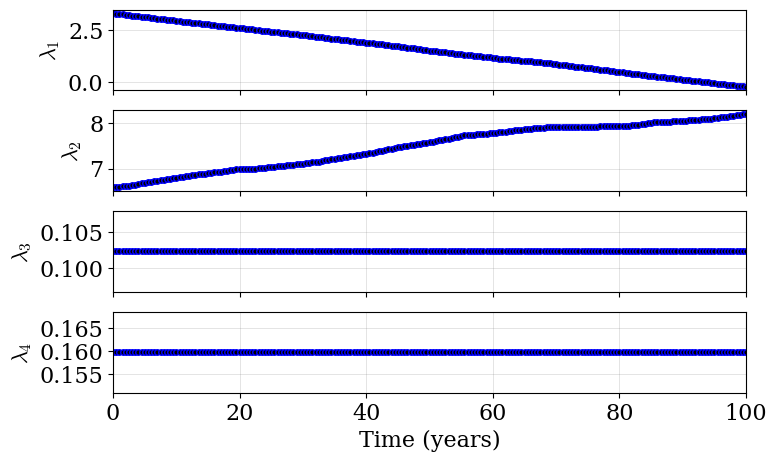

In [ ]:
# =========================
# PLOTAGEM DAS LAMBDAS – GLAM / ANN
# =========================
import matplotlib.pyplot as plt

### Figure name and DPI
dpi = 600
name = 'lambdas_glam_ann'

# =========================
# Dados
# =========================
data_glam = [
    {'x': time_vec, 'y': lambda1_glam},
    {'x': time_vec, 'y': lambda2_glam},
    {'x': time_vec, 'y': lambda3_glam},
    {'x': time_vec, 'y': lambda4_glam},
]

# =========================
# Figure
# =========================
fig, axes = plt.subplots(nrows=4, ncols=1, sharex=True, figsize=(b_input_total, h_input))

for i, (ax, dataset) in enumerate(zip(axes, data_glam)):
    ax.plot(dataset['x'], dataset['y'],
            marker=marker,
            markersize=size_marker,
            markerfacecolor=color_marker,
            linewidth=size_line,
            linestyle=style_line,
            color=color_line)

    ax.tick_params(axis='both', which='major', labelsize=size_axis, colors=color_axis)
    ax.set_ylabel(labels_legend[i], fontsize=size_label, color=color_label)
    ax.grid(on_or_off, which='both', linestyle=style_grid,
            linewidth=line_width_grid, color=color_grid, alpha=alpha_grid)
    ax.set_xlim(0, 100)

axes[-1].set_xlabel(label_x, fontsize=size_label, color=color_label)

plt.tight_layout()
#fig.savefig(f'z_{name}_en.png', dpi=dpi, bbox_inches='tight')
plt.show()


In [30]:
speedup = elapsed_real / elapsed_glam

print('\n==============================')
print('COMPARAÇÃO DE DESEMPENHO')
print('==============================')
print(f"Ground Truth : {elapsed_real:.4f} s")
print(f"GLAM / ANN   : {elapsed_glam:.6f} s")
print(f"Speed-up     : {speedup:.1f}x mais rápido")



COMPARAÇÃO DE DESEMPENHO
Ground Truth : 352.2085 s
GLAM / ANN   : 0.006252 s
Speed-up     : 56337.0x mais rápido
